In [1]:
import numpy as np
import matplotlib.pyplot as plt


def finitechange_2d(x0, x1, model, variable_names=None):
    """
    Low-cost finite-change analysis using 2d+2 model evaluations.

    It computes, for the direction x0 -> x1:

        first_i       = f(x1_i, x0_-i) - f(x0)

        total_i       = f(x1) - f(x0_i, x1_-i)

        interaction_i = total_i - first_i

    The total_i values are obtained by moving one variable at a time
    backwards from x1 to x0, then changing sign.

    Parameters
    ----------
    x0 : array-like
        Base-case vector.

    x1 : array-like
        Changed vector.

    model : callable
        Function y = model(x).

    variable_names : list of str, optional
        Variable names.

    Returns
    -------
    result : dict
        Dictionary containing y0, y1, dy, first, total, interaction,
        forward_outputs, backward_outputs, and variable_names.
    """

    x0 = np.asarray(x0, dtype=float).reshape(-1)
    x1 = np.asarray(x1, dtype=float).reshape(-1)

    d = len(x0)

    if variable_names is None:
        variable_names = [f"x{i+1}" for i in range(d)]

    # Base and final outputs
    y0 = model(x0)
    y1 = model(x1)
    dy = y1 - y0

    first = np.zeros(d)
    total = np.zeros(d)
    interaction = np.zeros(d)

    forward_outputs = np.zeros(d)
    backward_outputs = np.zeros(d)

    for i in range(d):

        # --------------------------------------------------
        # FIRST-ORDER EFFECT
        # Move only x_i from x0_i to x1_i
        # --------------------------------------------------
        x_forward = x0.copy()
        x_forward[i] = x1[i]

        y_forward = model(x_forward)
        forward_outputs[i] = y_forward

        first[i] = y_forward - y0

        # --------------------------------------------------
        # TOTAL EFFECT
        # Start from x1 and move only x_i back to x0_i
        # --------------------------------------------------
        x_backward = x1.copy()
        x_backward[i] = x0[i]

        y_backward = model(x_backward)
        backward_outputs[i] = y_backward

        # Backward change is y_backward - y1.
        # Change sign to obtain total effect in direction x0 -> x1.
        total[i] = y1 - y_backward

        # --------------------------------------------------
        # INTERACTION CONTRIBUTION
        # --------------------------------------------------
        interaction[i] = total[i] - first[i]

    result = {
        "x0": x0,
        "x1": x1,
        "y0": y0,
        "y1": y1,
        "dy": dy,
        "first": first,
        "total": total,
        "interaction": interaction,
        "forward_outputs": forward_outputs,
        "backward_outputs": backward_outputs,
        "variable_names": variable_names
    }

    return result

In [2]:
def plot_generalized_tornado_2d(result, sort_by="total"):
    """
    Generalized tornado diagram based on the 2d+2 finite-change analysis.

    For each variable, it plots:

        first-order effect
        interaction contribution
        total effect

    Parameters
    ----------
    result : dict
        Output of finitechange_2d.

    sort_by : str
        "total"       : sort by absolute total effect.
        "first"       : sort by absolute first-order effect.
        "interaction" : sort by absolute interaction effect.
    """

    names = result["variable_names"]
    first = np.asarray(result["first"])
    interaction = np.asarray(result["interaction"])
    total = np.asarray(result["total"])

    if sort_by == "total":
        impact = np.abs(total)
    elif sort_by == "first":
        impact = np.abs(first)
    elif sort_by == "interaction":
        impact = np.abs(interaction)
    else:
        raise ValueError("sort_by must be 'total', 'first', or 'interaction'.")

    idx = np.argsort(impact)[::-1]

    names = [names[i] for i in idx]
    first = first[idx]
    interaction = interaction[idx]
    total = total[idx]

    y = np.arange(len(names))

    fig, ax = plt.subplots(figsize=(10, 5))

    # First-order effect
    ax.barh(
        y - 0.22,
        first,
        height=0.20,
        color="steelblue",
        label="First-order effect"
    )

    # Interaction contribution
    ax.barh(
        y,
        interaction,
        height=0.20,
        color="orange",
        label="Interaction contribution"
    )

    # Total effect
    ax.barh(
        y + 0.22,
        total,
        height=0.20,
        color="black",
        alpha=0.75,
        label="Total effect"
    )

    ax.axvline(0, color="black", linewidth=1.5)

    ax.set_yticks(y)
    ax.set_yticklabels(names)

    ax.set_xlabel(r"Contribution to $\Delta y$")
    ax.set_title("Generalized Tornado Diagram")

    ax.legend()
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    plt.tight_layout()
    plt.show()

In [3]:
def print_finitechange_2d_table(result):
    """
    Print the 2d finite-change results.
    """

    names = result["variable_names"]
    first = result["first"]
    interaction = result["interaction"]
    total = result["total"]

    print("Finite-change 2d analysis")
    print("-------------------------")
    print(f"y0 = {result['y0']:.6f}")
    print(f"y1 = {result['y1']:.6f}")
    print(f"Δy = {result['dy']:.6f}")
    print()

    print(f"{'Variable':>10s} | {'First':>12s} | {'Interaction':>12s} | {'Total':>12s}")
    print("-" * 58)

    for name, f, inter, tot in zip(names, first, interaction, total):
        print(f"{name:>10s} | {f:12.6f} | {inter:12.6f} | {tot:12.6f}")

In [4]:
def model(x):
    """
    Ishigami function.
    """

    a = 7
    b = 0.1

    return (
        np.sin(x[0])
        + a * np.sin(x[1])**2
        + b * x[2]**4 * np.sin(x[0])
    )

In [7]:
x0 = np.array([1.5, 1.5, 1.5])
x1 = np.array([2.0, 2.0, 2.0])

variable_names = ["x1", "x2", "x3"]
result = finitechange_2d(
    x0,
    x1,
    model,
    variable_names=variable_names
)

In [8]:
print_finitechange_2d_table(result)

Finite-change 2d analysis
-------------------------
y0 = 8.467451
y1 = 8.151926
Δy = -0.315525

  Variable |        First |  Interaction |        Total
----------------------------------------------------------
        x1 |    -0.132848 |    -0.096466 |    -0.229314
        x2 |    -1.177221 |    -0.000000 |    -1.177221
        x3 |     1.091010 |    -0.096466 |     0.994544


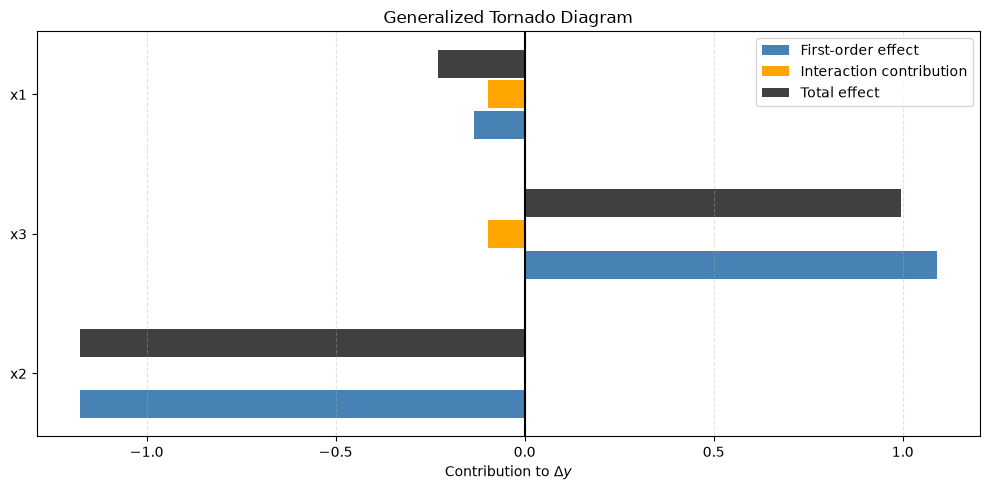

In [9]:
plot_generalized_tornado_2d(
    result,
    sort_by="total"
)